In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import json
from matplotlib import colormaps
import re
import io
from datetime import datetime

from src.utils import Extract_data_and_metadata
from src.plot import LM_dashboard, LM_plot_linear, LM_plot_log
#from src.export import export_csv
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# This code is used to plot the data from the FE tester for the CV
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

%config InlineBackend.figure_format = 'retina' # For high resolution figures in Jupyter Notebook
#%matplotlib widget

### WARNING

The script assume you only have one measurement per file

In [2]:
import os

file_paths = [
    r'E:\Polybox\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_05\Leakage measurement',
    r'E:\Polybox\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_01\Leakage measurement',
    r'E:\Polybox\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_03\Leakage measurement',
    r'E:\Polybox\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_06\Leakage measurement',
]

file_names = [
    '2026-02-02_NASA-FeCAP-05_ID00-28.dat',
    '2026-02-25_NASA-FeCAP-01_ID00-16.dat',
    '2026-02-25_NASA-FeCAP-03_ID01-21.dat',
    '2026-02-02_NASA-FeCAP-06_ID02-11_02.dat',
]

if len(file_names) != len(file_paths):
    raise ValueError("file_paths and file_names must have the same length")

full_paths = []
base_names = []
folder_names = []

for path, fname in zip(file_paths, file_names):

    full_path = os.path.join(path, fname)
    full_paths.append(full_path)

    # dossier parent (NASA_FeCAP_03)
    folder_names.append(os.path.basename(os.path.dirname(path)))

    # nom sans extension
    base_names.append(os.path.splitext(fname)[0])

print("Full paths:")
for p in full_paths:
    print(p)


Full paths:
E:\Polybox\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_05\Leakage measurement\2026-02-02_NASA-FeCAP-05_ID00-28.dat
E:\Polybox\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_01\Leakage measurement\2026-02-25_NASA-FeCAP-01_ID00-16.dat
E:\Polybox\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_03\Leakage measurement\2026-02-25_NASA-FeCAP-03_ID01-21.dat
E:\Polybox\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_06\Leakage measurement\2026-02-02_NASA-FeCAP-06_ID02-11_02.dat


In [3]:

List_DF = []

for path in full_paths:
    LM_dataframe, metadata_df = Extract_data_and_metadata(path)
    List_DF.append(LM_dataframe[0])


1 LM loaded.
1 LM loaded.
1 LM loaded.
1 LM loaded.


In [6]:
from matplotlib.ticker import AutoMinorLocator
import matplotlib.gridspec as gridspec

def LM_plot_linear_compare(
        List_DF: list[pd.DataFrame],
        labels: list[str],
        colors: list[str] | None = None,
        output_path: str = "",
        base_name: str = "",
        label_size: int = 15,
        tick_size: int = 15,
        figsize: tuple[int, int] = (9, 6),
        save: bool = True,
        show: bool = True,
):
    """
    Superpose multiple leakage measurements on a single linear plot.

    Parameters
    ----------
    List_DF : list[pd.DataFrame]
        List of leakage measurement DataFrames.
    labels : list[str]
        Labels to use in the legend (e.g. annealing temperatures).
        Must have the same length as List_DF.
    """

    output_dir = os.path.join(output_path, "LM_plots")
    os.makedirs(output_dir, exist_ok=True)

    if List_DF is None or len(List_DF) == 0:
        raise ValueError("List_DF must be a non-empty list of DataFrames.")

    if labels is None:
        raise ValueError("You must provide a list of labels for the legend.")

    if len(labels) != len(List_DF):
        raise ValueError("labels must have the same length as List_DF.")

    # ─────────────────────────────────────────────────────────────
    # Figure (ONE figure)
    # ─────────────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=figsize)

    for i, (df, label) in enumerate(zip(List_DF, labels)):

        V = np.asarray(df["Voltage [V]"], dtype=float)
        J = np.asarray(df["Leakage Current Density [uA/cm2]"], dtype=float)

        if colors is not None:
            color = colors[i]
        else:
            color = None  # matplotlib default, it's ugly 

        ax1.plot(
            V,
            J,
            marker="o",
            markersize=2.5,
            linewidth=1.4,
            label=label,
            color=color
        )


    # ─────────────────────────────────────────────────────────────
    # Axes labels
    # ─────────────────────────────────────────────────────────────
    ax1.set_xlabel("Voltage [V]", fontsize=label_size)
    ax1.set_ylabel("Leakage current density [µA/cm²]", fontsize=label_size)
    #ax1.set_yscale("log")
    ax1.set_title(base_name, fontsize=label_size)

    # ─────────────────────────────────────────────────────────────
    # Styling (Laura-friendly)
    # ─────────────────────────────────────────────────────────────
    ax1.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        labelsize=tick_size,
        length=6,
        width=1.2,
    )

    ax1.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax1.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.35)
    ax1.grid(True, which="minor", linestyle=":", linewidth=0.6, alpha=0.25)

    # ─────────────────────────────────────────────────────────────
    # Legend
    # ─────────────────────────────────────────────────────────────
    leg = ax1.legend(
        fontsize=label_size,
        frameon=True,
        loc="best",
    )
    leg.get_frame().set_linewidth(1.0)
    leg.get_frame().set_alpha(1.0)

    if show:
        plt.show()

    plt.close(fig)





def LM_plot_log_compare(
        List_DF: list[pd.DataFrame],
        labels: list[str],
        colors: list[str] | None = None,
        output_path: str = "",
        base_name: str = "",
        label_size: int = 15,
        tick_size: int = 15,
        figsize: tuple[int, int] = (9, 6),
        save: bool = True,
        show: bool = True,
):
    """
    Superpose multiple leakage measurements on a single linear plot.

    Parameters
    ----------
    List_DF : list[pd.DataFrame]
        List of leakage measurement DataFrames.
    labels : list[str]
        Labels to use in the legend (e.g. annealing temperatures).
        Must have the same length as List_DF.
    """

    output_dir = os.path.join(output_path, "LM_plots")
    os.makedirs(output_dir, exist_ok=True)

    if List_DF is None or len(List_DF) == 0:
        raise ValueError("List_DF must be a non-empty list of DataFrames.")

    if labels is None:
        raise ValueError("You must provide a list of labels for the legend.")

    if len(labels) != len(List_DF):
        raise ValueError("labels must have the same length as List_DF.")

    # ─────────────────────────────────────────────────────────────
    # Figure (ONE figure)
    # ─────────────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=figsize)

    for i, (df, label) in enumerate(zip(List_DF, labels)):

        V = np.asarray(df["Voltage [V]"], dtype=float)
        J = np.asarray(df["Leakage Current Density [uA/cm2]"], dtype=float)
        J = abs(J)

        if colors is not None:
            color = colors[i]
        else:
            color = None  # matplotlib default, it's ugly 

        ax1.plot(
            V,
            J,
            marker="o",
            markersize=2.5,
            linewidth=1.4,
            label=label,
            color=color
        )


    # ─────────────────────────────────────────────────────────────
    # Axes labels
    # ─────────────────────────────────────────────────────────────
    ax1.set_xlabel("Voltage [V]", fontsize=label_size)
    ax1.set_ylabel("Leakage current density [µA/cm²]", fontsize=label_size)
    ax1.set_yscale("log")
    ax1.set_title(base_name, fontsize=label_size)

    # ─────────────────────────────────────────────────────────────
    # Styling (Laura-friendly)
    # ─────────────────────────────────────────────────────────────
    ax1.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        labelsize=tick_size,
        length=6,
        width=1.2,
    )

    ax1.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax1.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.35)
    ax1.grid(True, which="minor", linestyle=":", linewidth=0.6, alpha=0.25)

    # ─────────────────────────────────────────────────────────────
    # Legend
    # ─────────────────────────────────────────────────────────────
    leg = ax1.legend(
        fontsize=label_size,
        frameon=True,
        loc="best",
    )
    leg.get_frame().set_linewidth(1.0)
    leg.get_frame().set_alpha(1.0)

    if show:
        plt.show()

    plt.close(fig)



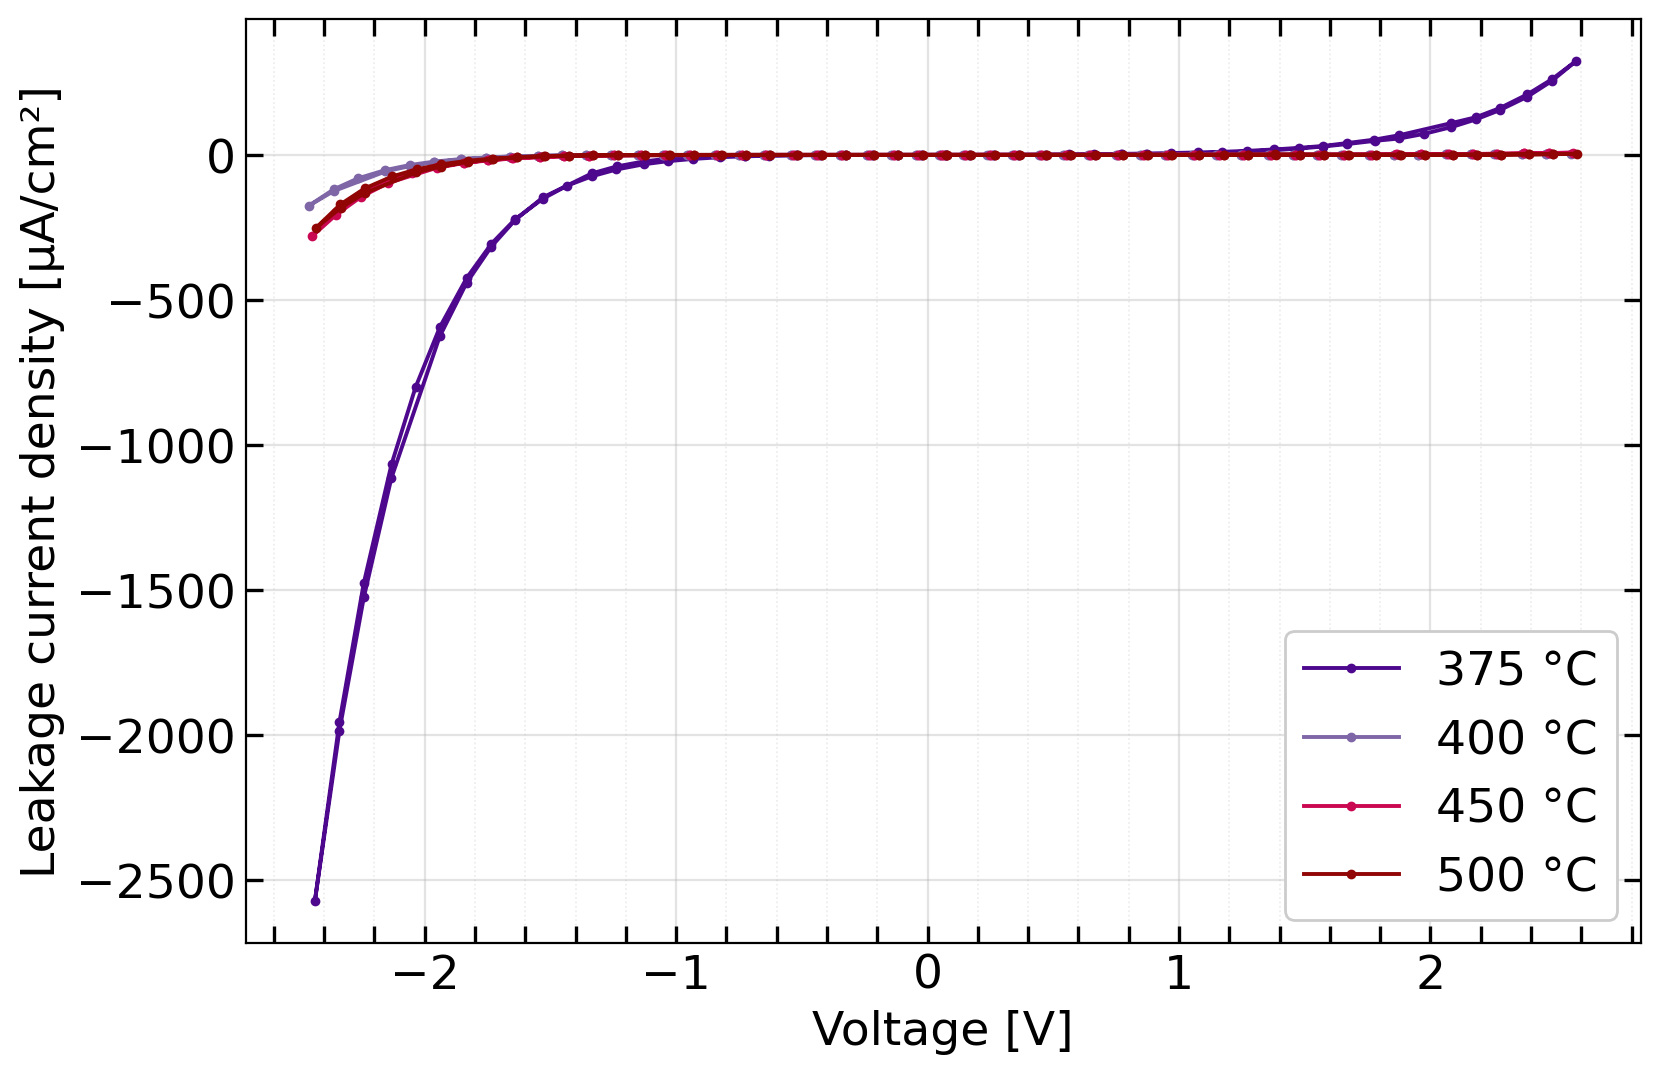

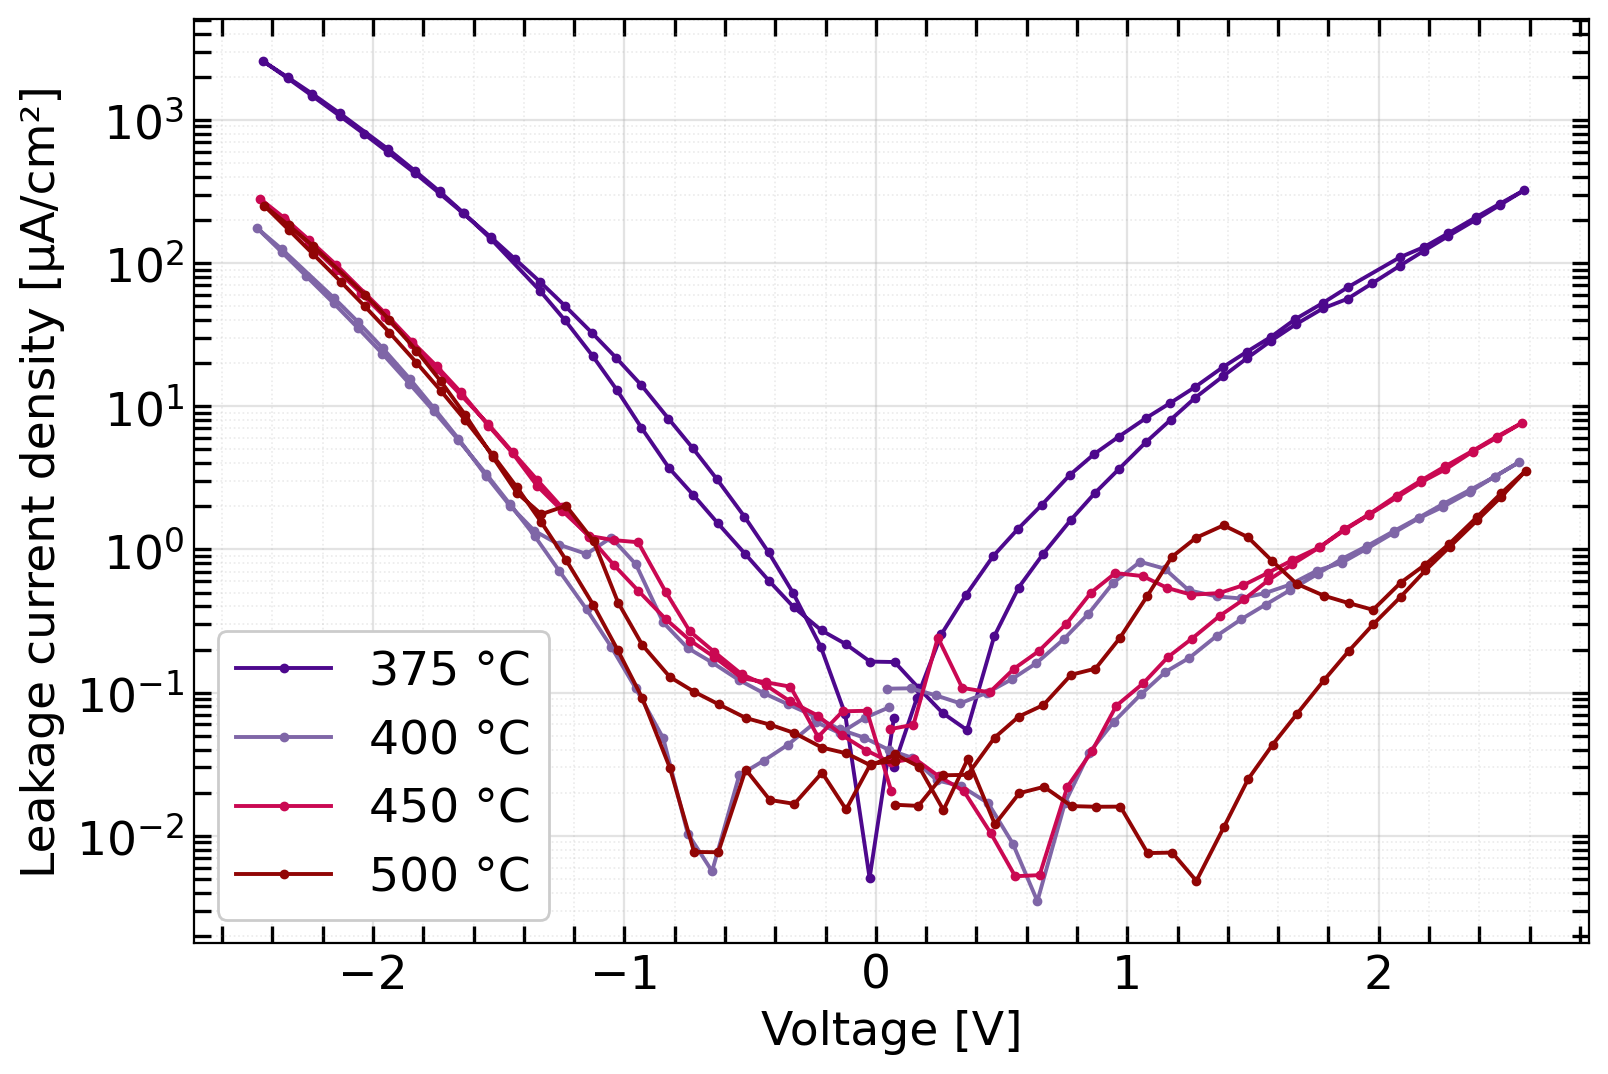

In [ ]:
labels = ["375 °C", "400 °C", "450 °C", "500 °C"]
colors = ["#4d088d", "#7f66a7", "#ca0852", "#910505"]

LM_plot_linear_compare(
    List_DF=List_DF,
    labels=labels,
    colors=colors,
    label_size=17,
    tick_size=17
)

LM_plot_log_compare(
    List_DF=List_DF,
    labels=labels,
    colors=colors,
    label_size=17,
    tick_size=17
)